In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('survey.csv')
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [2]:
# Drop unnecessary columns
df = df.drop(columns=['Timestamp', 'state', 'comments'])

# Clean 'Age' column
df.drop(df[df['Age'] < 0].index, inplace=True)
df.drop(df[df['Age'] > 100].index, inplace=True)

# Clean 'Gender' column
df['Gender'].replace(['Male ', 'male', 'M', 'm', 'Male', 'Cis Male',
                     'Man', 'cis male', 'Mail', 'Male-ish', 'Male (CIS)',
                     'Cis Man', 'msle', 'Malr', 'Mal', 'maile', 'Make'], 'Male', inplace=True)
df['Gender'].replace(['Female ', 'female', 'F', 'f', 'Woman', 'Female',
                     'femail', 'Cis Female', 'cis-female/femme', 'Femake', 'Female (cis)',
                     'woman'], 'Female', inplace=True)
df['Gender'].replace(['Female (trans)', 'queer/she/they', 'non-binary',
                     'fluid', 'queer', 'Androgyne', 'Trans-female', 'male leaning androgynous',
                     'Agender', 'A little about you', 'Nah', 'All',
                     'ostensibly male, unsure what that really means',
                     'Genderqueer', 'Enby', 'p', 'Neuter', 'something kinda male?',
                     'Guy (-ish) ^_^', 'Trans woman'], 'Other', inplace=True)

# Handle missing values
df['self_employed'].fillna('No', inplace=True)
df['work_interfere'].fillna('N/A', inplace=True)

print("Data cleaning complete. Missing values handled and 'Age'/'Gender' standardized.")
df.info()

Data cleaning complete. Missing values handled and 'Age'/'Gender' standardized.
<class 'pandas.core.frame.DataFrame'>
Index: 1254 entries, 0 to 1258
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Age                        1254 non-null   int64 
 1   Gender                     1254 non-null   object
 2   Country                    1254 non-null   object
 3   self_employed              1254 non-null   object
 4   family_history             1254 non-null   object
 5   treatment                  1254 non-null   object
 6   work_interfere             1254 non-null   object
 7   no_employees               1254 non-null   object
 8   remote_work                1254 non-null   object
 9   tech_company               1254 non-null   object
 10  benefits                   1254 non-null   object
 11  care_options               1254 non-null   object
 12  wellness_program           1254 non-null   

C:\Users\apple\AppData\Local\Temp\ipykernel_38628\1534865036.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace(['Male ', 'male', 'M', 'm', 'Male', 'Cis Male',
C:\Users\apple\AppData\Local\Temp\ipykernel_38628\1534865036.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

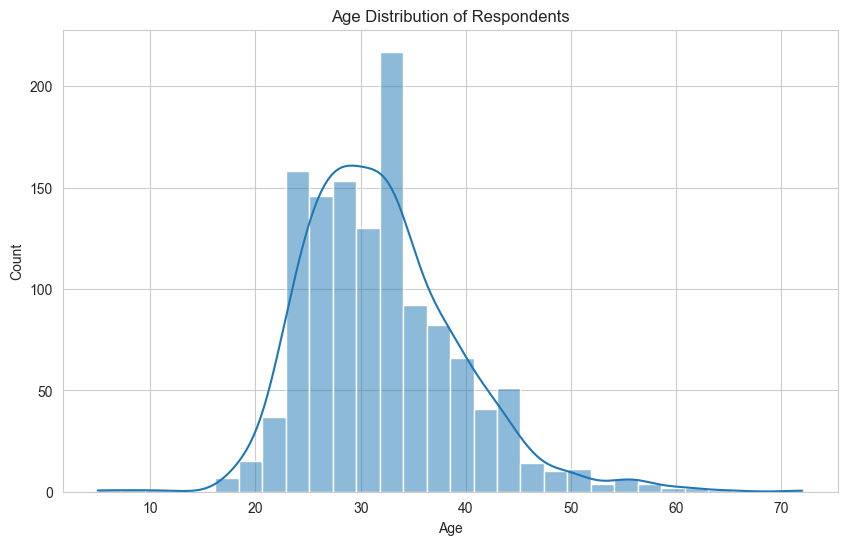

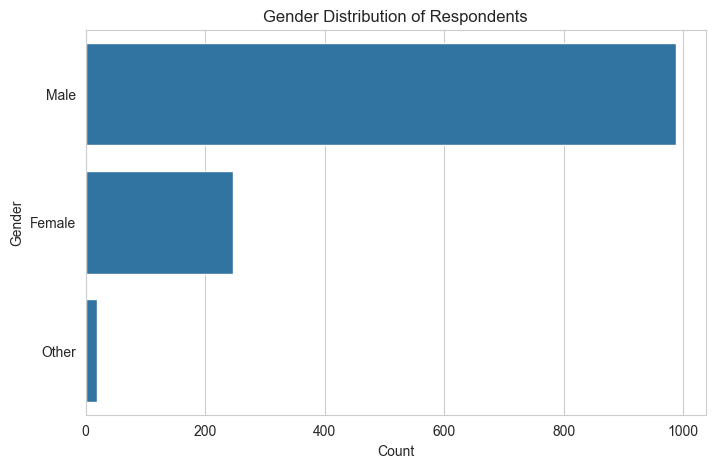

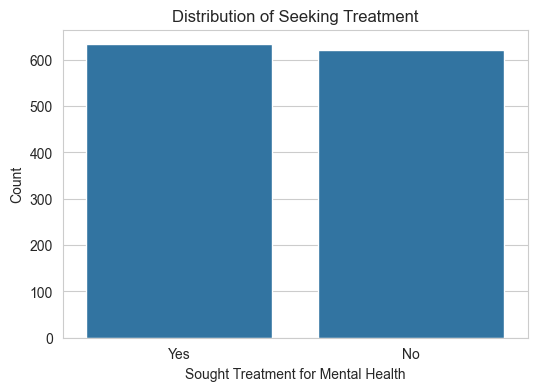

In [3]:
# Set plot style
sns.set_style('whitegrid')

# Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=30)
plt.title('Age Distribution of Respondents')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Gender distribution
plt.figure(figsize=(8, 5))
sns.countplot(y='Gender', data=df, order=df['Gender'].value_counts().index)
plt.title('Gender Distribution of Respondents')
plt.xlabel('Count')
plt.ylabel('Gender')
plt.show()

# Treatment distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='treatment', data=df)
plt.title('Distribution of Seeking Treatment')
plt.xlabel('Sought Treatment for Mental Health')
plt.ylabel('Count')
plt.show()

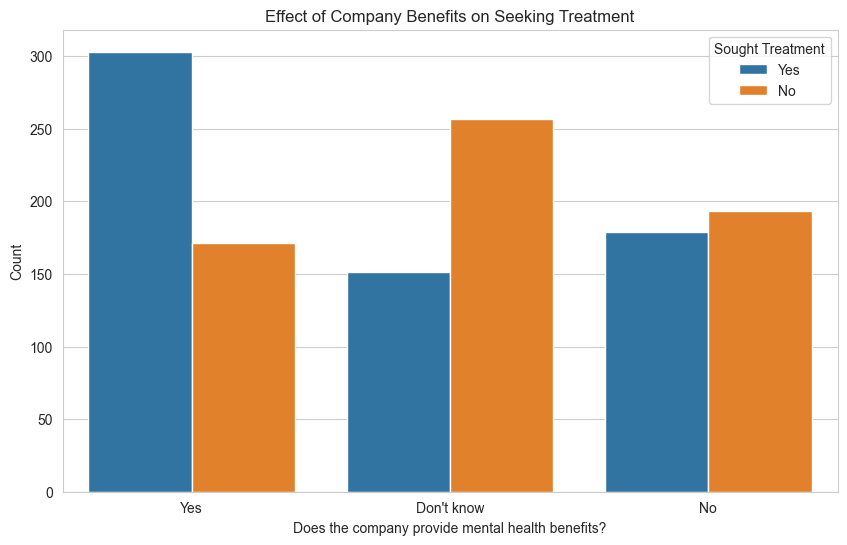

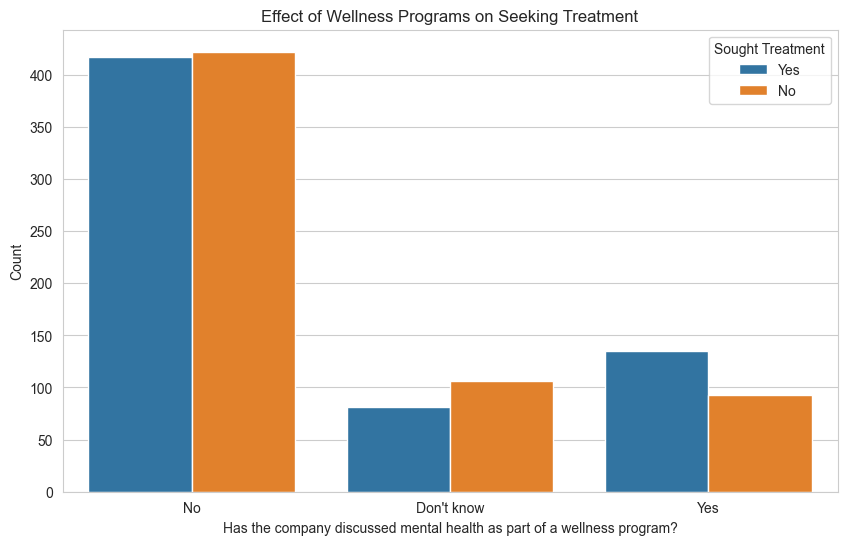

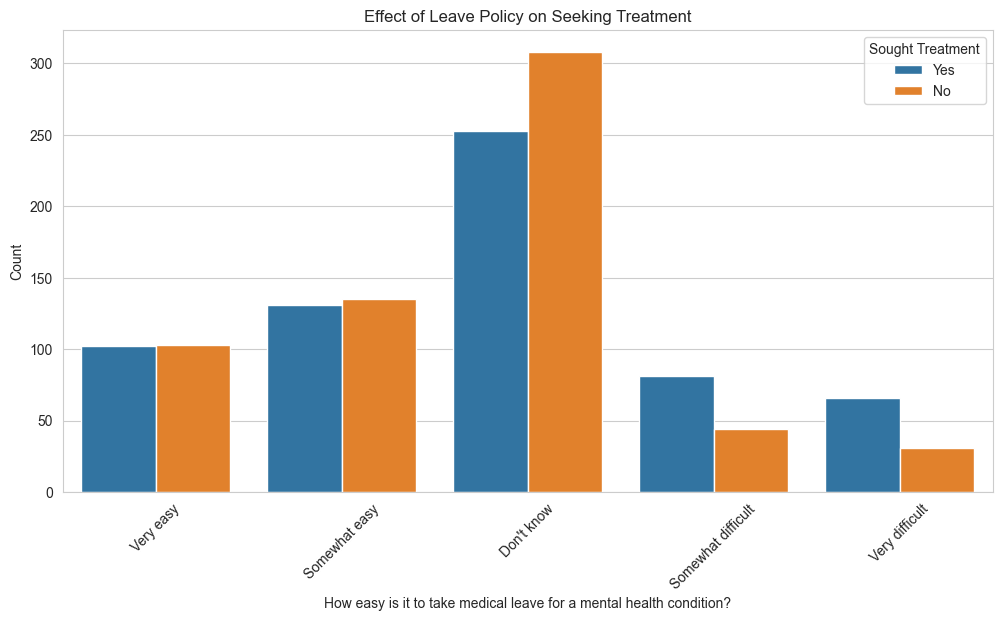

In [4]:
# Relationship between company benefits and seeking treatment
plt.figure(figsize=(10, 6))
sns.countplot(x='benefits', hue='treatment', data=df)
plt.title('Effect of Company Benefits on Seeking Treatment')
plt.xlabel('Does the company provide mental health benefits?')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.show()

# Relationship between wellness programs and seeking treatment
plt.figure(figsize=(10, 6))
sns.countplot(x='wellness_program', hue='treatment', data=df)
plt.title('Effect of Wellness Programs on Seeking Treatment')
plt.xlabel('Has the company discussed mental health as part of a wellness program?')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.show()

# Relationship between ease of taking medical leave and seeking treatment
plt.figure(figsize=(12, 6))
sns.countplot(x='leave', hue='treatment', data=df, order=['Very easy', 'Somewhat easy', "Don't know", 'Somewhat difficult', 'Very difficult'])
plt.title('Effect of Leave Policy on Seeking Treatment')
plt.xlabel('How easy is it to take medical leave for a mental health condition?')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Sought Treatment')
plt.show()

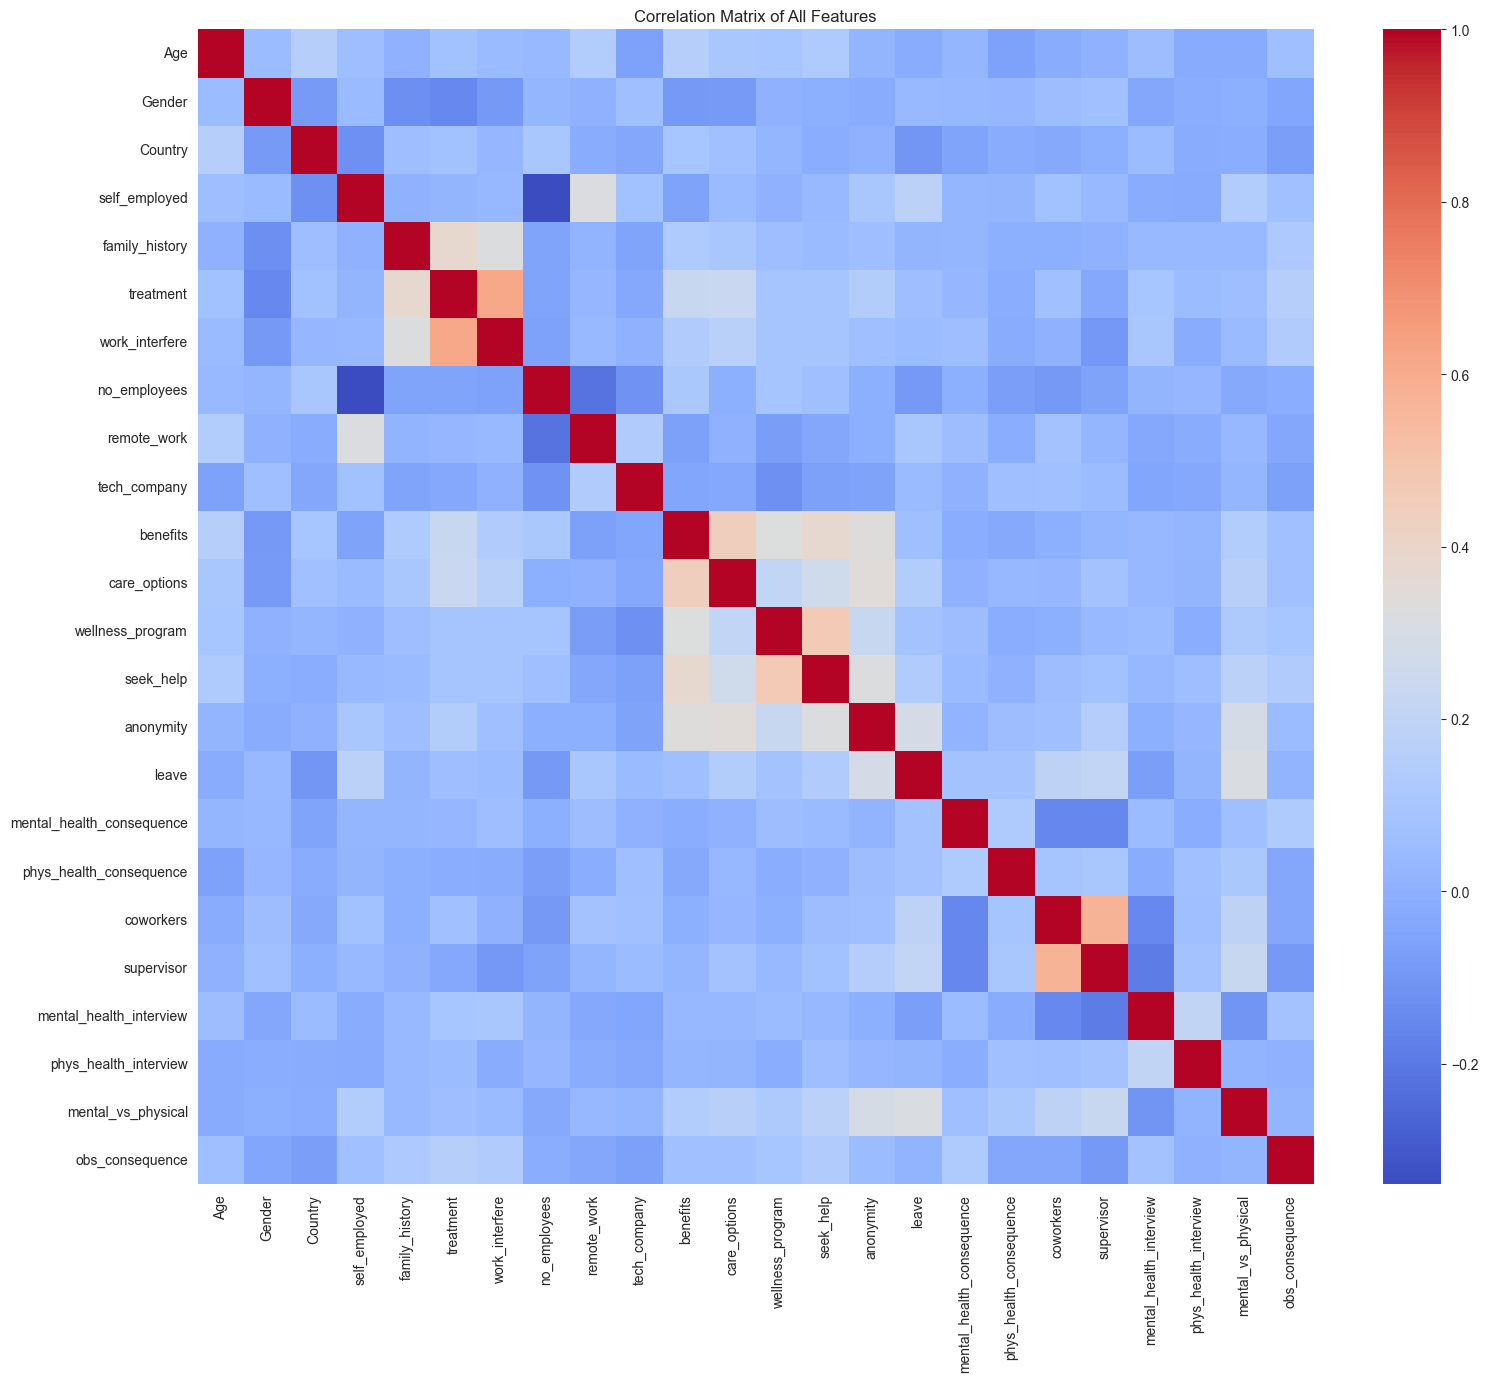

Top correlations with seeking treatment:
treatment                  1.000000
work_interfere             0.615324
family_history             0.378069
care_options               0.234806
benefits                   0.226160
obs_consequence            0.154541
anonymity                  0.142462
mental_health_interview    0.094744
wellness_program           0.092486
seek_help                  0.090009
Name: treatment, dtype: float64


In [5]:
from sklearn.preprocessing import LabelEncoder

# Create a copy for encoding
df_encoded = df.copy()

# Apply label encoding to all object columns
for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Calculate the correlation matrix
corr_matrix = df_encoded.corr()

# Plot the heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of All Features')
plt.show()

# Focus on correlations with 'treatment'
corr_treatment = corr_matrix['treatment'].sort_values(ascending=False)
print("Top correlations with seeking treatment:")
print(corr_treatment.head(10))